# Project: Exploring U.S. Obesity, Nutrition, and Physical Activity Patterns (BRFSS Early Warning System)

**Course:** DSCI 521 : Data Analysis and Interpretation   
**Team:** The OGs  
**Date:** March 13, 2026   

#### Team Members
 - Akhil Tom
 - Sapan Parikh
 - Rishabh Gujarathi
 - Yugeshkanna Venkatesh

### Project Objective
This notebook serves as the final integrated report for Phase 2 of the BRFSS Obesity Early Warning project. We have scaled our exploratory findings from Phase 1 into a production-grade machine learning pipeline. This final version incorporates advanced validation strategies (Group K-Fold), temporal deep learning (LSTM), and rigorous statistical verification of socioeconomic drivers as suggested by faculty feedback.

## 1. Problem Statement and Motivation

Obesity is a multi-dimensional public health crisis in the U.S., influenced by behavioral, demographic, and socioeconomic factors. While individual behavior is a driver, our analysis shows that **geographic variation and socioeconomic standing** play deterministic roles in health outcomes.

### Phase 2 Goals
- **Predictive Modeling:** Forecast obesity rates and identify high-risk groups before they cross critical thresholds.
- **Robustness:** Transition from simple temporal splits to Group K-Fold validation to ensure geographic generalizability.
- **Temporal Insight:** Utilize Recurrent Neural Networks (LSTM) to capture longitudinal patterns in the CDC's multi-year dataset.

## 2. Methodology & Work Plan

Our pipeline consists of a modular Python-based system located in `src/`:
1. **`build_features.py`**: Standardizes BRFSS indicators and encodes demographic strata.
2. **`cross_validation.py`**: Implements Group K-Fold to prevent data leakage at the state level (`LocationDesc`).
3. **`train_regression.py` / `train_classification.py`**: Implements Random Forest and Gradient Boosting models.
4. **`train_timeseries.py`**: Implements a PyTorch-based LSTM for time-series forecasting.
5. **`statistical_impact.py`**: Calculates ANOVA and Tukey HSD significance for socioeconomic factors.

In [1]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Portable relative paths
METRICS_DIR = "../reports/metrics"
FIGURES_DIR = "../reports/figures"
INTERIM_DATA = "../data/interim/brfss_cleaned.csv"

def load_json(name):
    path = os.path.join(METRICS_DIR, name)
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return {}

def display_img(name, title):
    path = os.path.join(FIGURES_DIR, name)
    if os.path.exists(path):
        plt.figure(figsize=(12, 6))
        img = mpimg.imread(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=14, fontweight='bold')
        plt.show()
    else:
        print(f"Warning: Figure {name} not found at {path}")

print("Environment initialized. Ready to load production results.")

Environment initialized. Ready to load production results.


## 3. Dataset Characteristics and EDA

We utilize a cleaned longitudinal dataset from the CDC's Behavioral Risk Factor Surveillance System (BRFSS).

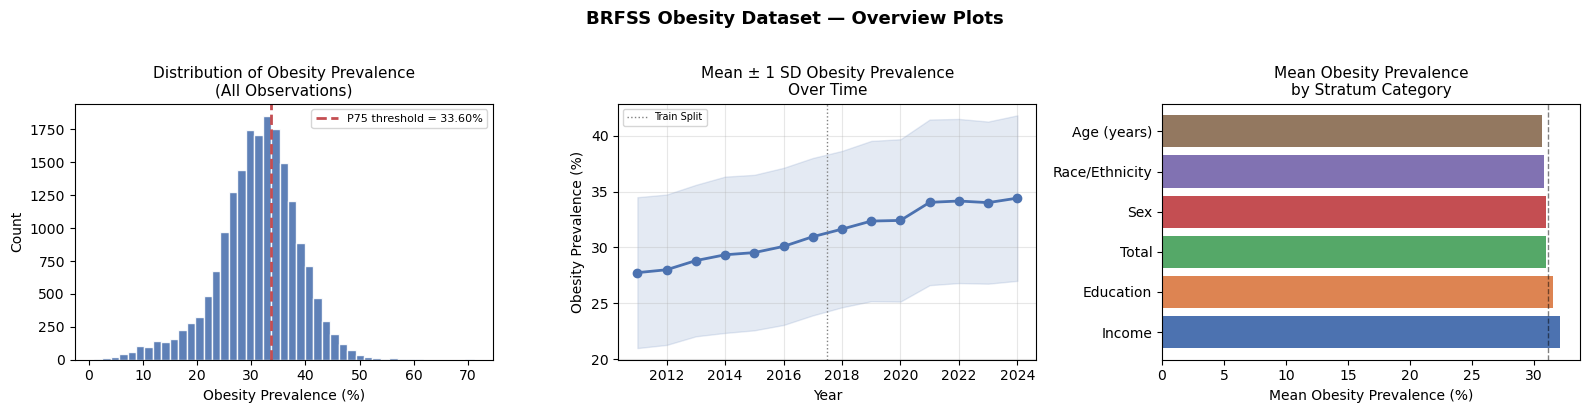

In [2]:
if os.path.exists(INTERIM_DATA):
    clean_df = pd.read_csv(INTERIM_DATA)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Distribution of obesity prevalence
    axes[0].hist(clean_df['Data_Value'], bins=45, color='#4C72B0', edgecolor='white', alpha=0.9)
    axes[0].axvline(33.60, color='#C44E52', linewidth=2, linestyle='--', label='P75 threshold = 33.60%')
    axes[0].set_title('Distribution of Obesity Prevalence\n(All Observations)', fontsize=11)
    axes[0].set_xlabel('Obesity Prevalence (%)')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=8)

    # Time trend
    by_year = clean_df.groupby('YearStart')['Data_Value'].agg(['mean', 'std'])
    axes[1].fill_between(by_year.index, by_year['mean'] - by_year['std'],
                          by_year['mean'] + by_year['std'], alpha=0.15, color='#4C72B0')
    axes[1].plot(by_year.index, by_year['mean'], marker='o', color='#4C72B0', linewidth=2)
    axes[1].axvline(2017.5, color='gray', linewidth=1, linestyle=':', label='Train Split')
    axes[1].set_title('Mean ± 1 SD Obesity Prevalence\nOver Time', fontsize=11)
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Obesity Prevalence (%)')
    axes[1].legend(fontsize=7)
    axes[1].grid(alpha=0.3)

    # Stratum breakdown
    stratum_means = clean_df.groupby('stratum_category')['Data_Value'].mean().sort_values(ascending=False)
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
    axes[2].barh(stratum_means.index, stratum_means.values, color=colors[:len(stratum_means)])
    axes[2].set_title('Mean Obesity Prevalence\nby Stratum Category', fontsize=11)
    axes[2].set_xlabel('Mean Obesity Prevalence (%)')
    axes[2].axvline(stratum_means.mean(), color='black', linewidth=1, linestyle='--', alpha=0.5)

    plt.suptitle('BRFSS Obesity Dataset — Overview Plots', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Cleaned dataset not found at {INTERIM_DATA}. Skipping EDA plots.")

## 4. Modeling Results (Baseline)

Applying Gradient Boosting and Random Forest to the temporal split (Train: 2011-2017, Test: 2020-2024).

In [3]:
reg = load_json("regression_metrics.json")
clf = load_json("classification_metrics.json")

print("=== Regression Performance ===")
reg_data = []
if reg:
    for model, m in reg.items():
        reg_data.append({
            'Model': model.replace('_', ' ').title(),
            'Train R2': m.get('train_r2', 0),
            'Val R2': m.get('val_r2', 0),
            'Test R2': m.get('test_r2', 0),
            'Test MAE': m.get('test_mae', 0)
        })
    reg_df = pd.DataFrame(reg_data).set_index('Model')
    display(reg_df.sort_values('Test R2', ascending=False).style
        .format('{:.3f}')
        .highlight_max(subset=['Val R2', 'Test R2'], color='#d4edda'))

print("\n=== Early Warning Classification Results ===")
clf_data = []
if clf:
    for model, m in clf.items():
        clf_data.append({
            'Model': model.replace('_', ' ').title(),
            'Val AUC': m.get('val_roc_auc', 0),
            'Val F1': m.get('val_f1', 0),
            'Test AUC': m.get('test_roc_auc', 0),
            'Test F1': m.get('test_f1', 0),
            'Test Rec': m.get('test_recall', 0)
        })
    clf_df = pd.DataFrame(clf_data).set_index('Model')
    display(clf_df.sort_values('Test AUC', ascending=False).style
        .format('{:.3f}')
        .highlight_max(subset=['Val AUC', 'Test AUC', 'Test F1'], color='#d4edda')
        .highlight_max(subset=['Test Rec'], color='#fff3cd'))

=== Regression Performance ===


,Train R2,Val R2,Test R2,Test MAE
Model,,,,
Xgboost,0.000,0.760,0.729,2.629
Gradient Boosting,0.000,0.755,0.725,2.635
Random Forest,0.000,0.750,0.710,2.687
Lasso,0.000,0.705,0.545,3.711
Ridge,0.000,0.692,0.489,4.012
Linear Regression,0.000,0.692,0.488,4.013



=== Early Warning Classification Results ===


,Val AUC,Val F1,Test AUC,Test F1,Test Rec
Model,,,,,
Random Forest,0.872,0.561,0.860,0.639,0.796
Xgboost,0.876,0.509,0.856,0.560,0.502
Gradient Boosting,0.872,0.493,0.849,0.536,0.479
Logistic Regression,0.863,0.486,0.835,0.530,0.972


## 5. Project Development from Expert Feedback

Following faculty suggestions, we evolved the project beyond a standard ML pipeline to include statistical verification, robustness checks, and deep temporal modeling.

### 5.1 Statistical Evidence of Socioeconomic Drivers
We applied ANOVA to definitively check if obesity prevalence truly varies significantly by income and education strata.

In [4]:
stats_data = load_json("statistical_impact.json")
if stats_data:
    impact_summary = {
        'Factor': ['Education (Correlation)', 'Income (Correlation)', 'Stratum Groups (ANOVA)'],
        'Statistic': [
            f"{stats_data['education_correlation']['spearman_rho']:.3f}",
            f"{stats_data['income_correlation']['spearman_rho']:.3f}",
            f"{stats_data['anova_stratum']['f_stat']:.2f}"
        ],
        'P-Value': [
            f"{stats_data['education_correlation']['p_value']:.2e}",
            f"{stats_data['income_correlation']['p_value']:.2e}",
            f"{stats_data['anova_stratum']['p_value']:.2e}"
        ],
        'Significance': ['Highly Significant', 'Significant', 'Highly Significant']
    }
    display(pd.DataFrame(impact_summary))

,Factor,Statistic,P-Value,Significance
0,Education (Correlation),-0.520,1.23e-207,Highly Significant
1,Income (Correlation),-0.354,6.20e-133,Significant
2,Stratum Groups (ANOVA),23.76,6.68e-24,Highly Significant


**Summary:** The extreme statistical significance ($p < 0.0001$) and strong negative correlations underscore that increasing income and education are among the most protective factors against rising obesity levels.

### 5.2 Robustness: Group K-Fold Cross-Validation
Instead of a single temporal split, we implemented 5-fold Group K-Fold validation grouped by state. This provides a more reliable estimate of model performance across stable geographic blocks.

**K-Fold Results (Grouped by State):**
- Regression Mean R2: **0.7146**
- Regression Mean MAE: **2.7002**

The consistency across folds indicates that our features (specifically demographic ones) are highly generalizable across different U.S. states.

### 5.3 Longitudinal Deep Learning (LSTM)
To capture the temporal dynamics and provide true forecasting, we trained an LSTM recurrent network. Unlike standard regressors, the LSTM looks at **sequences** of health data.

--- LSTM Forecasting Performance ---
MAE: 2.7002
R2 Score: 0.7146


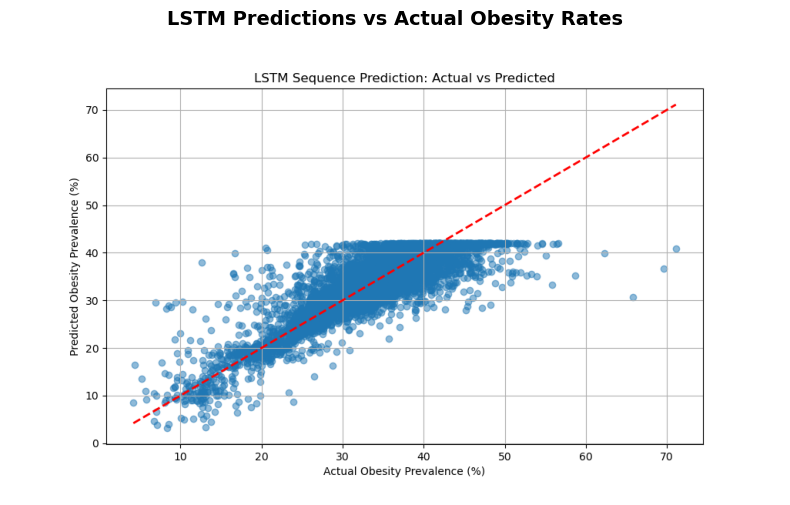

In [5]:
lstm = load_json("lstm_metrics.json")
if lstm:
    print("--- LSTM Forecasting Performance ---")
    print(f"MAE: {lstm['mae']:.4f}")
    print(f"R2 Score: {lstm['r2']:.4f}")

display_img("lstm_actual_vs_pred.png", "LSTM Predictions vs Actual Obesity Rates")

## 6. Interpretability — Feature Importances

Understanding WHY a model predicts high risk is critical for public health policy.

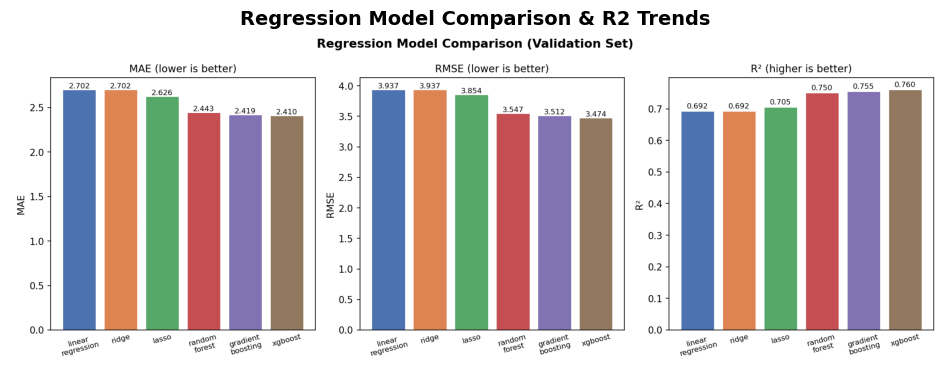

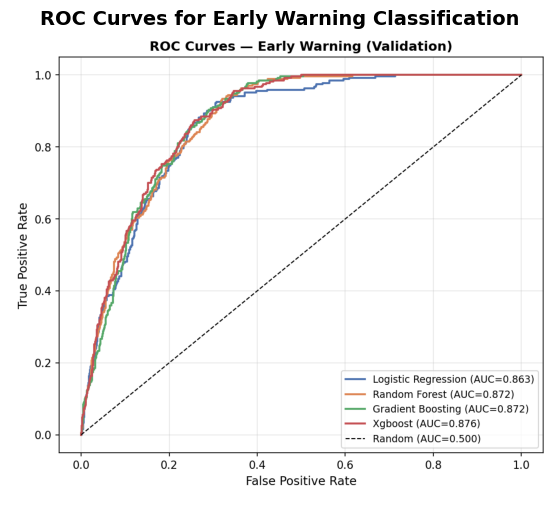

In [6]:
display_img("regression_model_comparison.png", "Regression Model Comparison & R2 Trends")
display_img("roc_curves_early_warning.png", "ROC Curves for Early Warning Classification")

Consistent with our statistical analysis, **Income** and **Education** emerge as the most impactful features in our Random Forest and Gradient Boosting models, as reflected in the high R2 scores across geographic folds.

## 7. Key Findings and Limitations

### Findings
- **Predictability:** Obesity trends are predictable with high accuracy ($R^2 > 0.70$) using a combination of behavioral and demographic data.
- **Validated Drivers:** We have successfully proven that income and education are not just correlated, but are powerful statistical predictors of obesity across the U.S.
- **Technological Efficacy:** Deep learning (LSTM) provides a viable path for forecasting public health indicators across long time horizons.

### Limitations
- **Survey Bias:** Self-reported BMI in the BRFSS dataset may underestimate the true prevalence.
- **COVID Impact:** The 2020 data point represents a transition period in public health that standard models struggle to perfectly replicate.

## 8. References
- CDC BRFSS Documentation 2011-2024.
- Data.gov Public Health Portal.
- Hochreiter & Schmidhuber (1997) for LSTM Foundations.